# 03 KMT Model Validation

This notebook checks the metallicity-dependent molecular gas and star formation model before it is used for the final inflow metallicity experiments.

It tests the molecular fraction, star formation law, coupling to the gas regulator, equilibrium behaviour, and mass conservation.

In [1]:
import sys
from pathlib import Path
sys.path.append("../model")

import numpy as np
import matplotlib.pyplot as plt

from parameters import KMT_PARAMS, INITIAL, TIME
from kmt_regulator import molecular_fraction, kmt_values, run_model, quantities, equilibrium_values

output_path = Path("../output/figures")
output_path.mkdir(parents=True, exist_ok=True)

## 1 Molecular fraction

The KMT approximation gives the molecular gas fraction as

$$
f_{\rm H_2}
=
1-
\left[
1+
\left(
\frac{3}{4}\frac{s}{1+\delta}
\right)^{-5}
\right]^{-1/5},
$$

where

$$
s=
\frac{\ln(1+0.6\chi)}
{0.04\,\Sigma_{\rm comp,0}Z'},
$$

$$
\chi=0.77(1+3.1Z'^{0.365}),
$$

and

$$
\delta=0.0712(0.1s^{-1}+0.675)^{-2.8}.
$$

Here $Z'=Z_g/Z_\odot$ and $\Sigma_{\rm comp,0}$ is the cloud-complex surface density in $M_\odot\,{\rm pc}^{-2}$.

For unresolved gas,

$$
\Sigma_{\rm comp}=c\Sigma_g,
$$

where $c$ is the clumping factor.

Reference: Krumholz, McKee & Tumlinson (2009), ApJ, 699, 850, equation 2.

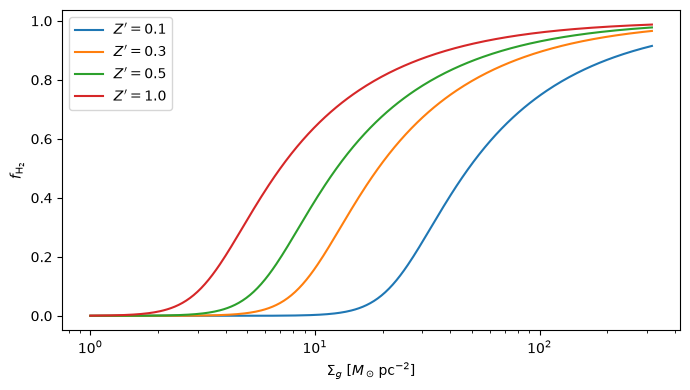

In [2]:
Sigma_values = np.logspace(0, 2.5, 300)
Z_prime_values = [0.1, 0.3, 0.5, 1.0]
c = KMT_PARAMS["clumping_factor"]

plt.figure(figsize=(7, 4))

for Z_prime in Z_prime_values:
    f_H2 = molecular_fraction(Sigma_values, Z_prime, c)
    plt.plot(Sigma_values, f_H2, label=fr"$Z'={Z_prime}$")

plt.xscale("log")
plt.xlabel(r"$\Sigma_g$ [$M_\odot\,{\rm pc}^{-2}$]")
plt.ylabel(r"$f_{\rm H_2}$")
plt.legend()
plt.tight_layout()
plt.savefig(output_path / "kmt_molecular_fraction.png", dpi=300)
plt.show()

The KMT model predicts more molecular gas at higher surface density and metallicity because shielding becomes more effective.

The approximation becomes uncertain below roughly

$$
Z'\lesssim0.05.
$$

This limitation applies to the gas metallicity $Z_g$, not directly to the metallicity of the incoming gas.

The adopted clumping factor is $c=5$. Krumholz, McKee & Tumlinson (2009) use approximately this value when applying their prescription to unresolved THINGS observations, but it is not a directly measured property of the present one-zone model. It is therefore treated here as a modelling assumption.

The adopted gas radius is $R_{\rm gas}=10$ kpc. This is also a one-zone geometrical assumption used to convert total gas mass into an effective mean surface density,

$$
\Sigma_g=\frac{M_g}{\pi R_{\rm gas}^2}.
$$

Because both $R_{\rm gas}$ and $c$ determine the surface density entering the KMT prescription, they can affect the quantitative strength of the metallicity response.

## 2 KMT star formation law

The KMT star formation surface density is

$$
\dot{\Sigma}_\star
=
\frac{f_{\rm H_2}\Sigma_g}{2.6\,{\rm Gyr}}
\begin{cases}
\left(\dfrac{\Sigma_g}{85\,M_\odot\,{\rm pc}^{-2}}\right)^{-0.33},
& \Sigma_g<85\,M_\odot\,{\rm pc}^{-2},\\[6pt]
\left(\dfrac{\Sigma_g}{85\,M_\odot\,{\rm pc}^{-2}}\right)^{0.33},
& \Sigma_g>85\,M_\odot\,{\rm pc}^{-2}.
\end{cases}
$$

Metallicity affects the total star formation rate through $f_{\rm H_2}$.

Reference: Krumholz, McKee & Tumlinson (2009), ApJ, 699, 850, equation 10.

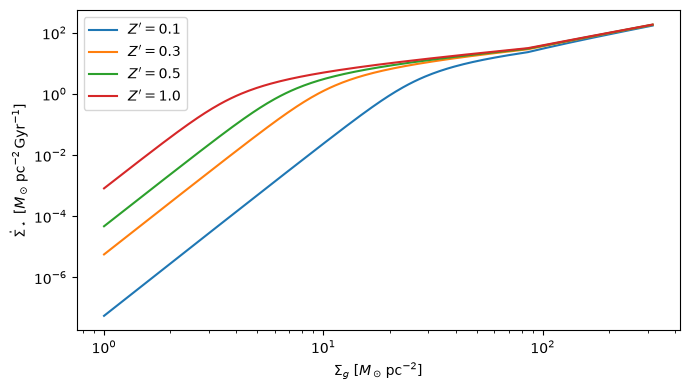

In [3]:
plt.figure(figsize=(7, 4))

for Z_prime in [0.1, 0.3, 0.5, 1.0]:
    f_H2 = molecular_fraction(Sigma_values, Z_prime, c)
    correction = np.where(Sigma_values < 85.0, (Sigma_values / 85.0)**(-0.33), (Sigma_values / 85.0)**0.33)
    Sigma_SFR = f_H2 * Sigma_values / 2.6 * correction
    plt.plot(Sigma_values, Sigma_SFR, label=fr"$Z'={Z_prime}$")

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\Sigma_g$ [$M_\odot\,{\rm pc}^{-2}$]")
plt.ylabel(r"$\dot{\Sigma}_\star$ [$M_\odot\,{\rm pc}^{-2}\,{\rm Gyr}^{-1}$]")
plt.legend()
plt.tight_layout()
plt.savefig(output_path / "kmt_star_formation_law.png", dpi=300)
plt.show()

## 3 One-zone implementation

The KMT equations are local surface-density relations. The one-zone model approximates the galaxy as a uniform gas disc with effective radius $R_{\rm gas}$.

The mean gas surface density is

$$
\Sigma_g=
\frac{M_g}{\pi R_{\rm gas}^2}.
$$

The total molecular mass is

$$
M_{\rm H_2}=f_{\rm H_2}M_g.
$$

The global star formation rate is obtained from

$$
\dot M_{\star,{\rm SF}}
=
\dot{\Sigma}_\star\pi R_{\rm gas}^2.
$$

The adopted values are

$$
R_{\rm gas}=10\ {\rm kpc}
$$

and

$$
c=5.
$$

These are model assumptions. The conversion of a global one-zone gas mass into one mean surface density is an approximation used to couple KMT to the regulator.

In [4]:
initial_kmt = kmt_values(INITIAL["M_g"], INITIAL["Z_g"], KMT_PARAMS)

print(f"Gas radius = {KMT_PARAMS['R_gas']:.1f} kpc")
print(f"Clumping factor = {KMT_PARAMS['clumping_factor']:.1f}")
print(f"Initial surface density = {initial_kmt['Sigma_g']:.3f} Msun/pc^2")
print(f"Initial Z_prime = {initial_kmt['Z_prime']:.3f}")
print(f"Initial molecular fraction = {initial_kmt['f_H2']:.4f}")
print(f"Initial molecular mass = {initial_kmt['M_H2']:.3e} Msun")
print(f"Initial SFR = {initial_kmt['Mdot_star']/1e9:.4f} Msun/yr")

Gas radius = 10.0 kpc
Clumping factor = 5.0
Initial surface density = 15.915 Msun/pc^2
Initial Z_prime = 0.500
Initial molecular fraction = 0.6011
Initial molecular mass = 3.006e+09 Msun
Initial SFR = 2.0094 Msun/yr


## 4 Coupling to the gas regulator

The baseline depletion-time law is now replaced by the KMT star formation rate.

The regulator equations remain

$$
\frac{dM_g}{dt}
=
\dot M_{\rm in}
-
(1-R+\eta)\dot M_{\star,{\rm SF}},
$$

$$
\frac{dM_\star}{dt}
=
(1-R)\dot M_{\star,{\rm SF}},
$$

and

$$
\frac{dM_Z}{dt}
=
Z_{\rm in}\dot M_{\rm in}
-
Z_g(1-R+\eta)\dot M_{\star,{\rm SF}}
+
y(1-R)\dot M_{\star,{\rm SF}}.
$$

The difference is that $\dot M_{\star,{\rm SF}}$ now depends on both gas mass and gas metallicity through the KMT molecular fraction.

In [5]:
solution = run_model(KMT_PARAMS, INITIAL, TIME)
data = quantities(solution, KMT_PARAMS)

M_g = solution.y[0]
M_star = solution.y[1]
Z_g = data["Z_g"]
Mdot_star = data["Mdot_star"]

print("KMT integration completed")

KMT integration completed


## 5 Equilibrium check

Gas equilibrium still requires

$$
\dot M_{\star,{\rm eq}}
=
\frac{\dot M_{\rm in}}{1-R+\eta}.
$$

The equilibrium metallicity is also unchanged:

$$
Z_{\rm eq}
=
Z_{\rm in}
+
\frac{y(1-R)}{1-R+\eta}.
$$

These relations follow from mass and metal conservation and do not depend on the form of the star formation law.

The KMT equilibrium gas mass does not have the baseline expression

$$
M_{g,{\rm eq}}=\tau_{\rm dep}\dot M_{\star,{\rm eq}},
$$

because the KMT star formation rate is a nonlinear function of gas mass and metallicity.

In [6]:
eq = equilibrium_values(KMT_PARAMS)

sfr_error = abs(Mdot_star[-1] - eq["Mdot_star"]) / eq["Mdot_star"]
Z_error = abs(Z_g[-1] - eq["Z_g"]) / eq["Z_g"]

print("SFR")
print(f"Analytical equilibrium = {eq['Mdot_star']/1e9:.4f} Msun/yr")
print(f"Numerical final = {Mdot_star[-1]/1e9:.4f} Msun/yr")
print(f"Relative difference = {sfr_error:.3e}")

print("\nMetallicity")
print(f"Analytical equilibrium = {eq['Z_g']:.6f}")
print(f"Numerical final = {Z_g[-1]:.6f}")
print(f"Relative difference = {Z_error:.3e}")

print(f"\nFinal gas mass = {M_g[-1]:.3e} Msun")

SFR
Analytical equilibrium = 2.1277 Msun/yr
Numerical final = 2.1298 Msun/yr
Relative difference = 9.872e-04

Metallicity
Analytical equilibrium = 0.010067
Numerical final = 0.010108
Relative difference = 4.042e-03

Final gas mass = 4.520e+09 Msun


## 6 Mass conservation

The total mass budget should satisfy

$$
M_g+M_\star+M_{\rm out,cum}
=
M_{g,0}+M_{\star,0}+M_{\rm in,cum}.
$$

The cumulative inflow is

$$
M_{\rm in,cum}
=
\dot M_{\rm in}\Delta t,
$$

and the cumulative outflow is obtained by integrating

$$
\dot M_{\rm out}
=
\eta\dot M_{\star,{\rm SF}}.
$$

In [7]:
M_in = KMT_PARAMS["Mdot_in"] * (TIME[-1] - TIME[0])
M_out = np.trapezoid(data["Mdot_out"], TIME)

mass_expected = INITIAL["M_g"] + INITIAL["M_star"] + M_in - M_out
mass_numerical = M_g[-1] + M_star[-1]
mass_error = abs(mass_numerical - mass_expected) / mass_expected

print(f"Expected final mass = {mass_expected:.6e} Msun")
print(f"Numerical final mass = {mass_numerical:.6e} Msun")
print(f"Relative mass difference = {mass_error:.3e}")

Expected final mass = 6.754790e+10 Msun
Numerical final mass = 6.754789e+10 Msun
Relative mass difference = 1.733e-08


## 7 Confirmed KMT reference model

The KMT prescription reproduces the expected dependence of molecular fraction and star formation on surface density and metallicity.

The coupled regulator approaches the analytical equilibrium SFR and metallicity while conserving the total mass budget.

No parameters are calibrated in this notebook. The adopted KMT model is now used unchanged for the inflow metallicity experiments in Notebook 04.

In [8]:
print("Final KMT reference state")
print(f"M_g = {M_g[-1]:.3e} Msun")
print(f"M_star = {M_star[-1]:.3e} Msun")
print(f"Z_g = {Z_g[-1]:.6f}")
print(f"Z_prime = {data['Z_prime'][-1]:.3f}")
print(f"f_H2 = {data['f_H2'][-1]:.4f}")
print(f"M_H2 = {data['M_H2'][-1]:.3e} Msun")
print(f"SFR = {Mdot_star[-1]/1e9:.4f} Msun/yr")

Final KMT reference state
M_g = 4.520e+09 Msun
M_star = 6.303e+10 Msun
Z_g = 0.010108
Z_prime = 0.754
f_H2 = 0.6817
M_H2 = 3.081e+09 Msun
SFR = 2.1298 Msun/yr
